In [2]:
# Import libraries
import json
import sys
from pathlib import Path
from typing import cast, Optional, Dict, Any
from dataclasses import asdict
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from pydantic import BaseModel, Field
from dotenv import load_dotenv

load_dotenv(override=True)

notebook_dir = Path.cwd()
prompt_dir = notebook_dir.parent / "prompts"
state_dir = notebook_dir.parent / "state_types"
util_dir = notebook_dir.parent / "utils"

d:\Python\student_depression\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys
sys.path.append(str(notebook_dir.parent))

from state_types.state import (ChatState, UserProfile, Gender, SleepDuration, DietaryHabits, 
                               Degree, IntakerOutput, Intent, IntentClassifierOutput)

from utils.utils import (get_last_user_message, load_prompt, initialize_workflow,
                        get_next_agent, mark_agent_completed, 
                        create_supervisor_update_with_workflow_init,
                        get_workflow_description)

In [4]:
# LLM instances
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

llm_super = ChatOpenAI(model="gpt-4o", temperature=0)

intaker_llm = llm.with_structured_output(IntakerOutput)

print("Setup complete.")

Setup complete.


### Agent node Implement

In [4]:
def intaker_node(state: ChatState) -> Command:
    messages = state.get("messages", [])
    user_text = get_last_user_message(messages)
    current_profile = state.get("profile", {})

    prompt = f"""
        {load_prompt('11_intaker_agent.md', prompts_dir=str(prompt_dir))}

        CURRENT PROFILE:
        {current_profile}
        USER INPUT:
        {user_text}
    """

    response = cast(IntakerOutput, intaker_llm.invoke([
        SystemMessage(content=prompt),
        HumanMessage(content=user_text)
    ]))
    
    new_profile = {**current_profile}
    if response.profile:
        for k, v in asdict(response.profile).items():
            if v is not None:
                new_profile[k] = v

    profile = UserProfile.model_construct(**new_profile)
    missing_fields = profile.get_missing_fields()

    update: Dict[str, Any] = {
        **state,
        "profile": new_profile,
        "missing_fields": missing_fields,
        **(mark_agent_completed(state, "intaker") if not missing_fields else {}),
    }

    return Command(
        update=update,
        goto="waiting_for_user" if missing_fields else "supervisor"
    )

In [5]:
def waiting_for_user_node(state: ChatState) -> Command:
    missing_fields = state.get("missing_fields", [])
    prompt = f""" 
        {load_prompt('12_waiting_for_user_agent.md', prompts_dir=str(prompt_dir))}

        MISSING FIELDS: {missing_fields}
    """

    result = llm.invoke([
        SystemMessage(content=prompt),
    ])

    response = result.content

    return Command(
        update = {
            **state,
            "messages": state.get("messages", []) + [AIMessage(content=result.content)]
        },
        goto=END
    )

In [6]:
def direct_response_node(state: ChatState) -> Command:
    messages = state.get("messages", [])
    user_text = get_last_user_message(messages)

    prompt = f"""
        {load_prompt('13_responder_agent.md', prompts_dir=str(prompt_dir))}
    """

    result = llm.invoke([
        SystemMessage(content=prompt),
        HumanMessage(content=user_text)
    ])

    return Command(
        update = {
            **state,
            "messages": state.get("messages", []) + [AIMessage(content=result.content)]
        },
        goto=END
    )

### RAG NODE

In [53]:
import sys
from pathlib import Path
from pinecone import Pinecone
from langchain_community.retrievers import PineconeHybridSearchRetriever
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parent))

# Import từ rag package
from rag.retriever import (
    load_config_from_env,
    create_embeddings,
    load_bm25,
)

In [7]:
bm25_path = notebook_dir.parent.parent / "model" / "rag" / "artifacts" / "bm25_encoder.pkl"

In [8]:
# Load retriever (đã có)
config = load_config_from_env()
embeddings = create_embeddings("sentence-transformers/all-MiniLM-L6-v2")

bm25 = load_bm25(bm25_path)
pc = Pinecone(api_key=config.api_key)
index = pc.Index(config.index_name)
retriever = PineconeHybridSearchRetriever(
    embeddings=embeddings,
    sparse_encoder=bm25,
    index=index,
    top_k=3,
)

system_prompt = load_prompt('14_rag_response_agent.md', prompts_dir=str(prompt_dir))
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}")
])

question_answer_chain = create_stuff_documents_chain(llm, rag_prompt)
rag_chain = create_retrieval_chain(retriever, question_answer_chain)

print("✓ RAG chain initialized (reusable)")


d:\Python\student_depression\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


BM25 encoder loaded from d:\Python\student_depression\model\rag\artifacts\bm25_encoder.pkl
✓ RAG chain initialized (reusable)


In [9]:
def rag_retriever(query: str) -> list:
    docs = retriever.invoke(query)
    return docs

In [ ]:
def rag_qa_node(state: ChatState) -> Command:
    messages = state.get("messages", [])
    user_text = get_last_user_message(messages)

    retrieved_docs = rag_retriever(user_text)

    prompt_template = ChatPromptTemplate.from_messages([
        SystemMessage(content=load_prompt('14_rag_qa_agent.md', prompts_dir=str(prompt_dir))),
        HumanMessage(content="{user_query}"),
    ])

    chain = create_retrieval_chain(
        llm=llm,
        retriever=lambda _: retrieved_docs,
        document_combiner=create_stuff_documents_chain(llm=llm, prompt=prompt_template),
    )

    result = chain.invoke({
        "user_query": user_text
    })

    return Command(
        update = {
            **state,
            "messages": state.get("messages", []) + [AIMessage(content=result['text'])]
        },
        goto=END
    )

### Evaluate and adivise node

In [ ]:
def build_advice_retrieval_query(user_text: str, profile: dict, prediction: Any) -> str:
    """Build a context-rich query for RAG retrieval (grounding docs)."""
    pred_label = ""
    pred_score = ""
    if isinstance(prediction, dict):
        pred_label = str(prediction.get("label") or prediction.get("risk_label") or prediction.get("class") or "")
        pred_score = str(prediction.get("score") or prediction.get("probability") or prediction.get("risk_score") or "")

    salient_keys = [
        "age", "gender", "sleep_duration", "dietary_habits",
        "study_hours", "academic_pressure", "study_satisfaction",
        "financial_stress", "family_history", "suicidal_thoughts"
    ]
    salient = {k: profile.get(k) for k in salient_keys if profile.get(k) is not None}

    safety_focus = ""
    if profile.get("suicidal_thoughts") is True:
        safety_focus = (
            "\nSafety priority: user indicates suicidal thoughts. Retrieve crisis/safety guidance, "
            "when to seek urgent help, safety planning, and how to encourage reaching out."
        )

    return (
        "Task: Retrieve evidence-based guidance passages for a student mental health assistant.\n"
        f"User request: {user_text}\n"
        f"Risk screening signal (NOT diagnosis): label={pred_label}, score={pred_score}\n"
        f"User profile key factors: {json.dumps(salient, ensure_ascii=False)}\n"
        "Need documents covering:\n"
        "- Practical coping steps (sleep, routine, stress, study workload)\n"
        "- When to seek professional help (red flags, escalation)\n"
        "- How to talk about feelings and social support\n"
        f"{safety_focus}\n"
        "Return passages suitable to cite in a short advice message.\n"
    )

In [ ]:
def eva_adv_node(state: ChatState) -> Command:
    messages = state.get("messages", []) or []
    user_text = get_last_user_message(messages)
    profile = state.get("profile", {}) or {}
    prediction = state.get("prediction")

    if not profile or not prediction:
        return Command(
            update={
                **state,
                "messages": messages + [AIMessage(content="Insufficient data to provide advice. Please complete the intake process.")],
                **mark_agent_completed(state, "advisor_agent"),
            },
            goto=END,
        )

    # 1) Build enriched retrieval query (state-aware)
    rag_query = build_advice_retrieval_query(user_text, profile, prediction)

    # 2) Retrieve docs using rag_query (NOT user_text)
    retrieved_docs = rag_retriever(rag_query)

    # 3) Use an advice prompt that includes {context}
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", load_prompt("15_evaluate_and_advise_agent.md", prompts_dir=str(prompt_dir))),
        ("human",
         "USER REQUEST:\n{user_query}\n\n"
         "USER PROFILE:\n{user_profile}\n\n"
         "PREDICTION (screening only, not diagnosis):\n{prediction}\n\n"
         "GROUNDED CONTEXT (retrieved docs):\n{context}\n"
        ),
    ])

    # 4) Stuff docs into {context} and generate answer
    stuff_chain = create_stuff_documents_chain(llm=llm, prompt=prompt_template)

    answer_text = stuff_chain.invoke({
        "user_query": user_text,
        "user_profile": json.dumps(profile, ensure_ascii=False),
        "prediction": json.dumps(prediction, ensure_ascii=False),
        "context": retrieved_docs,  # must be "context"
    })

    return Command(
        update={
            **state,
            "messages": messages + [AIMessage(content=answer_text)],
            **mark_agent_completed(state, "advisor_agent"),
        },
        goto="supervisor",
    )

### Predict Node

In [20]:
import joblib
from pathlib import Path
predict_dir = notebook_dir.parent / "predict"
sys.path.append(str(predict_dir))

In [16]:
from helper import transform_profile_to_features, load_model_and_scaler
from predict import predict_from_profile

# Load model và scaler
model_scaler_path = notebook_dir.parent.parent / "model" / "predict"
predict_model, predict_scaler = load_model_and_scaler(str(model_scaler_path))

print("✓ Prediction model loaded")

✓ Prediction model loaded


In [17]:
# ===== DUMMY STATE FOR TESTING PREDICTION =====

# Test case 1: High risk profile
dummy_state_high_risk = {
    "profile": {
        "gender": "Female",
        "age": 22,
        "academic_pressure": 5,
        "study_satisfaction": 2,
        "study_hours": 12.0,
        "degree": "BSc",
        "cgpa": 2.5,
        "sleep_duration": "Less than 5 hours",
        "dietary_habits": "Unhealthy",
        "suicidal_thoughts": True,
        "family_history": True,
        "financial_stress": 5
    },
    "messages": [],
    "missing_fields": []
}

# Test case 2: Low risk profile
dummy_state_low_risk = {
    "profile": {
        "gender": "Male",
        "age": 20,
        "academic_pressure": 2,
        "study_satisfaction": 4,
        "study_hours": 6.0,
        "degree": "BA",
        "cgpa": 3.8,
        "sleep_duration": "7-8 hours",
        "dietary_habits": "Healthy",
        "suicidal_thoughts": False,
        "family_history": False,
        "financial_stress": 1
    },
    "messages": [],
    "missing_fields": []
}

# Test case 3: Moderate risk profile
dummy_state_moderate_risk = {
    "profile": {
        "gender": "Female",
        "age": 23,
        "academic_pressure": 2,
        "study_satisfaction": 1,
        "study_hours": 5.0,
        "degree": "B.Tech",
        "cgpa": 3.2,
        "sleep_duration": "5-6 hours",
        "dietary_habits": "Moderate",
        "suicidal_thoughts": False,
        "family_history": False,
        "financial_stress": 1
    },
    "messages": [],
    "missing_fields": []
}

print("✓ Dummy states created")

✓ Dummy states created


In [ ]:
def predict_node(state: ChatState) -> Command:
    profile = state.get("profile", {})
    if not profile:
        raise ValueError("Profile data is missing in state.")
    
    profile = state.get("profile", {})
    pred_result = predict_from_profile(
        profile,
        model=predict_model,
        scaler=predict_scaler
    )
    
    update: Dict[str, Any] = {
        **state,
        "prediction": pred_result,
        **mark_agent_completed(state, "predictor"),
    }
    
    return Command(update=update, goto="supervisor")

### Supervisor Agent

In [19]:
def detect_intent(messages: list) -> Intent:
    """Detect intent from user message using LLM."""
    llm_intent = llm_super.with_structured_output(IntentClassifierOutput)

    user_text = get_last_user_message(messages)
    
    if not user_text:
        return "UNKNOWN"
    
    prompt = f"""{load_prompt("10_router_agent.md", prompts_dir=str(prompt_dir))}

        USER MESSAGE: "{user_text}"
        """
    
    out = cast(IntentClassifierOutput, llm_intent.invoke([
        SystemMessage(content=prompt),
        HumanMessage(content=user_text)
    ]))
    
    return out.intent

print("Intent detection configured")

Intent detection configured


In [ ]:
def supervisor_node(state: ChatState) -> Command:
    messages = state.get("messages", []) or []
    pending_agents = state.get("pending_agents", []) or []
    completed_agents = state.get("completed_agents", []) or []
    intent = state.get("intent")

    if not intent:
        detected_intent = detect_intent(messages)
        
        if detected_intent in ["UNKNOWN", "DIRECT_RESPONSE"]:
            update = {
                "intent": detected_intent,
                "messages": messages + [AIMessage(content=f"[Supervisor] Detected intent: '{detected_intent}'")]
            }
            return Command(update=update, goto="direct_responder")
        
        workflow_update, intent, pending_agents = create_supervisor_update_with_workflow_init(
            detected_intent, state
        )
        
        if not workflow_update:
            return Command(
                update={"messages": [AIMessage(content=f"[Supervisor] Intent '{detected_intent}' not supported")]},
                goto=END
            )
        
        next_agent = pending_agents[0] if pending_agents else None
        if next_agent:
            debug_msg = f"[Supervisor] → '{next_agent}' | Pending: {pending_agents} | Completed: {completed_agents}"
            update = {
                **state,
                **workflow_update,
                "messages": [AIMessage(content=debug_msg)],
            }
            return Command(update=update, goto=next_agent)
        
    if len(pending_agents) == 0:
        return Command(
            update={
                **state,
                "intent": None,
                "pending_agents": [],
                "completed_agents": [],
            },
            goto=END
        )

    next_agent = pending_agents[0]
    debug_msg = f"[Supervisor] → '{next_agent}' | Pending: {pending_agents} | Completed: {completed_agents}"

    return Command(
        update={
            **state, 
            "messages": messages + [AIMessage(content=debug_msg)]},
        goto=next_agent
    )   

### Build graph

In [ ]:
graph = StateGraph(ChatState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("intaker", intaker_node)
graph.add_node("waiting_for_user", waiting_for_user_node)
graph.add_node("direct_responder", direct_response_node)
graph.add_node("advisor", eva_adv_node)
graph.add_node("rag_responder", rag_qa_node)
graph.add_node("predict", predict_node)

graph.set_entry_point("supervisor")

memory = MemorySaver()
app = graph.compile(checkpointer=memory)

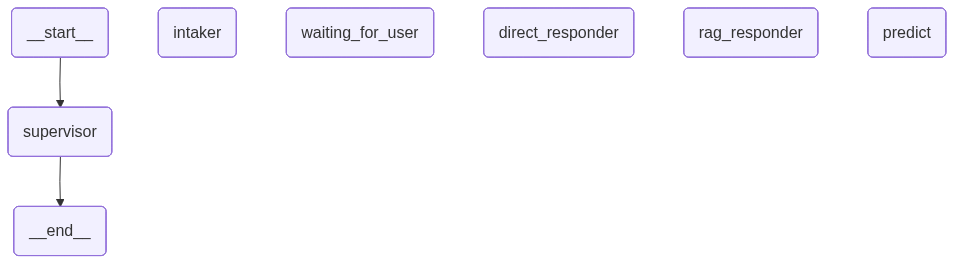

In [23]:
display(Image(app.get_graph().draw_mermaid_png()))

### Invoke graph

In [24]:
thread_config = {"configurable": {"thread_id": "lklk"}}

In [25]:
input_1 = {
    "messages": [
        HumanMessage(content="Hello"),
    ]
}

result = app.invoke(input_1, thread_config)

In [26]:
result

{'intent': 'UNKNOWN',
 'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='568d8b7a-df5b-498a-b6fe-20f97883309f'),
  AIMessage(content="[Supervisor] Detected intent: 'UNKNOWN'", additional_kwargs={}, response_metadata={}, id='e9453d8c-75b1-4e5e-8339-bc766b20c89d', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="Hello! I'm here to help you with mental health support and student well-being. How can I assist you today?", additional_kwargs={}, response_metadata={}, id='30d5bd4b-71da-4ee2-9e87-88464bde9172', tool_calls=[], invalid_tool_calls=[])]}